## Produces **Mosquito Predictions** for a specific region using MAMOTH ##

In [1]:
import pandas as pd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys

sys.path.insert(0, "../../../Mamoth Modules")
sys.path.insert(0, "../../../Modules")

from preprocessing_utils import *

from Preprocessing_Module import read_data, select_columns, reshape_dataset
from Initializer_Module import initializer
from Neural_Network_Module import Dataset, transformations, FeedforwardNeuralNetModel, train_nn, give_predictions
from Model_Validation_Module import validation_plots, metrics

enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 10

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\tqdm\auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
NUTS0 = 'GR'
NUTS2 = 'Thessaly'
NUTS2_EL = 'θεσσαλιας'

In [4]:
dataset = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_Biweekly_2023-May_filled.csv', encoding=enc)


In [5]:
dataset.head()

,lau1,region,x,y,dt_placement,year,month,indices_image_date,indices_lat,indices_lon,ndvi_new,ndmi_new,ndwi_new,ndbi_new,ndvi_mean_new,ndmi_mean_new,ndwi_mean_new,ndbi_mean_new,ndvi_std_new,ndmi_std_new,ndwi_std_new,ndbi_std_new,lst_image_date,lst_lat,lst_lon,lst_day_new,lst_night_new,monthly_lst_lat,monthly_lst_lon,lst_jan_day_mean_new,lst_jan_night_mean_new,lst_feb_day_mean_new,lst_feb_night_mean_new,lst_mar_day_mean_new,lst_mar_night_mean_new,lst_apr_day_mean_new,lst_apr_night_mean_new,indices_image_date.1,indices_lat.1,indices_lon.1,acc_rainfall_jan_new,dt_placement_minus_7,dt_placement_minus_14,dt_placement_minus_7_avail,dt_placement_minus_14_avail,acc_rainfall_1week_new,acc_rainfall_2week_new
0,αγιας,θεσσαλιας,22.63715,39.66477,2023-05-01,2023,5,2023-04-30,39.662866,22.635299,0.320605,0.010753,-0.297699,-0.010753,0.505039,0.205061,-0.442851,-0.205061,0.125752,0.119283,0.096853,0.119283,2023-05-01,39.662866,22.635299,14966.0,14353.0,39.662866,22.635299,14219.000000,13818.000000,14307.062500,13704.263158,14637.352941,13943.333333,14850.466667,14041.625000,2023-05-01,39.650181,22.650104,70.551421,2023-04-24,2023-04-17,2023-04-24,2023-04-17,0.462882,28.530567
1,αγιας,θεσσαλιας,22.63715,39.66477,2023-05-16,2023,5,2023-05-15,39.662866,22.635299,0.240125,-0.026575,-0.239737,0.026575,0.378440,0.113461,-0.354095,-0.113461,0.096435,0.088987,0.075341,0.088987,2023-05-15,39.662866,22.635299,14659.0,13889.0,39.662866,22.635299,14219.000000,13818.000000,14307.062500,13704.263158,14637.352941,13943.333333,14850.466667,14041.625000,2023-05-16,39.650181,22.650104,91.643375,2023-05-09,2023-05-02,2023-05-09,2023-05-02,11.616080,20.296991
2,αγιας,θεσσαλιας,22.70702,39.75460,2023-05-01,2023,5,2023-04-30,39.752697,22.707165,0.506922,0.087536,-0.458373,-0.087536,0.521654,0.109084,-0.459319,-0.109084,0.056933,0.073780,0.034842,0.073780,2023-05-01,39.752697,22.707165,14569.0,14025.0,39.752697,22.707165,14223.600000,13741.846154,14084.133333,13737.714286,14400.923077,13793.692308,14395.000000,13897.142857,2023-05-01,39.750182,22.750104,80.850409,2023-04-24,2023-04-17,2023-04-24,2023-04-17,2.064366,13.038493
3,αγιας,θεσσαλιας,22.70702,39.75460,2023-05-16,2023,5,2023-05-15,39.752697,22.707165,0.506922,0.087536,-0.458373,-0.087536,0.521654,0.109084,-0.459319,-0.109084,0.056933,0.073780,0.034842,0.073780,2023-05-15,39.752697,22.707165,14401.0,14149.0,39.752697,22.707165,14223.600000,13741.846154,14084.133333,13737.714286,14400.923077,13793.692308,14395.000000,13897.142857,2023-05-16,39.750182,22.750104,112.728533,2023-05-09,2023-05-02,2023-05-09,2023-05-02,16.491027,26.945055
4,αγιας,θεσσαλιας,22.73031,39.79054,2023-05-01,2023,5,2023-04-30,39.788630,22.729622,0.398340,-0.021568,-0.405003,0.021568,0.148230,0.267161,-0.058763,-0.267161,0.041401,0.077481,0.012572,0.077481,2023-05-01,39.788630,22.729622,14419.0,13927.0,39.788630,22.729622,14031.307692,13745.444444,13840.846154,13747.428571,14317.428571,13781.400000,14333.600000,13838.888889,2023-05-01,39.750182,22.750104,80.850409,2023-04-24,2023-04-17,2023-04-24,2023-04-17,2.064366,13.038493


In [6]:
dataset.rename(columns={"region": "nuts2"}, inplace=True)

In [7]:
dataset = dataset.rename(columns=lambda x: re.sub('_new', '', x))

In [8]:
dataset.drop(columns=['indices_image_date', 'indices_lat', 'indices_lon' , 'lst_image_date', 'lst_lat','lst_lon' ,'monthly_lst_lat', 'monthly_lst_lon', 
                         'indices_image_date.1', 'indices_lat.1', 'indices_lon.1', 'dt_placement_minus_7', 'dt_placement_minus_14', 'dt_placement_minus_7_avail',
                         'dt_placement_minus_14_avail'], inplace = True)

In [9]:
dataset.head(5)

,lau1,nuts2,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week
0,αγιας,θεσσαλιας,22.63715,39.66477,2023-05-01,2023,5,0.320605,0.010753,-0.297699,-0.010753,0.505039,0.205061,-0.442851,-0.205061,0.125752,0.119283,0.096853,0.119283,14966.0,14353.0,14219.000000,13818.000000,14307.062500,13704.263158,14637.352941,13943.333333,14850.466667,14041.625000,70.551421,0.462882,28.530567
1,αγιας,θεσσαλιας,22.63715,39.66477,2023-05-16,2023,5,0.240125,-0.026575,-0.239737,0.026575,0.378440,0.113461,-0.354095,-0.113461,0.096435,0.088987,0.075341,0.088987,14659.0,13889.0,14219.000000,13818.000000,14307.062500,13704.263158,14637.352941,13943.333333,14850.466667,14041.625000,91.643375,11.616080,20.296991
2,αγιας,θεσσαλιας,22.70702,39.75460,2023-05-01,2023,5,0.506922,0.087536,-0.458373,-0.087536,0.521654,0.109084,-0.459319,-0.109084,0.056933,0.073780,0.034842,0.073780,14569.0,14025.0,14223.600000,13741.846154,14084.133333,13737.714286,14400.923077,13793.692308,14395.000000,13897.142857,80.850409,2.064366,13.038493
3,αγιας,θεσσαλιας,22.70702,39.75460,2023-05-16,2023,5,0.506922,0.087536,-0.458373,-0.087536,0.521654,0.109084,-0.459319,-0.109084,0.056933,0.073780,0.034842,0.073780,14401.0,14149.0,14223.600000,13741.846154,14084.133333,13737.714286,14400.923077,13793.692308,14395.000000,13897.142857,112.728533,16.491027,26.945055
4,αγιας,θεσσαλιας,22.73031,39.79054,2023-05-01,2023,5,0.398340,-0.021568,-0.405003,0.021568,0.148230,0.267161,-0.058763,-0.267161,0.041401,0.077481,0.012572,0.077481,14419.0,13927.0,14031.307692,13745.444444,13840.846154,13747.428571,14317.428571,13781.400000,14333.600000,13838.888889,80.850409,2.064366,13.038493


In [10]:
grouped = dataset.groupby(['dt_placement', 'lau1', 'nuts2'], as_index = False)
dataset = grouped.mean()
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week
0,2023-05-01,αγιας,θεσσαλιας,22.750267,39.710970,2023.0,5.0,0.509207,0.119405,-0.451816,-0.119405,0.531592,0.254587,-0.428750,-0.254587,0.077768,0.058778,0.056475,0.058778,14608.285714,14153.000000,14158.229570,13810.607919,14132.381348,13770.111663,14483.438175,13900.012383,14528.540407,14007.143707,76.675988,2.381410,17.837466
1,2023-05-01,αλμυρου,θεσσαλιας,22.692366,39.136391,2023.0,5.0,0.645191,0.302370,-0.529492,-0.302370,0.618919,0.280067,-0.511682,-0.280067,0.056373,0.054701,0.034039,0.054701,14633.444444,14200.333333,14236.213555,13871.070700,14235.830525,13815.772792,14503.039805,14000.498550,14640.452078,14072.106614,208.946587,3.480882,69.269711
2,2023-05-01,αλοννησου,θεσσαλιας,24.073790,39.328960,2023.0,5.0,0.493058,0.137236,-0.431136,-0.137236,0.499103,0.137082,-0.425521,-0.137082,0.036059,0.052143,0.019232,0.052143,14533.000000,14299.000000,14303.111111,14120.666667,14247.800000,14074.285714,14424.133333,14144.066667,14543.000000,14215.666667,163.677945,7.946645,55.220344
3,2023-05-01,αργιθεας,θεσσαλιας,21.430513,39.221380,2023.0,5.0,0.597637,0.302454,-0.493106,-0.302454,0.560003,0.257320,-0.465701,-0.257320,0.040313,0.053018,0.024440,0.053018,14526.000000,13953.000000,13984.796537,13767.640659,13972.290278,13581.276389,14264.541026,13850.111111,14318.077381,13868.033333,141.474393,8.412601,10.754827
4,2023-05-01,βολου,θεσσαλιας,22.883800,39.351977,2023.0,5.0,0.510673,0.128033,-0.451844,-0.128033,0.513199,0.149993,-0.449576,-0.149993,0.048106,0.049815,0.032318,0.049815,14920.000000,14251.333333,14310.624820,13874.456288,14320.436508,13834.927778,14589.631410,13978.820513,14708.583333,14067.142857,146.622452,1.161971,49.566698
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45,2023-05-16,τεμπων,θεσσαλιας,22.553160,39.852112,2023.0,5.0,0.511804,0.199036,-0.425108,-0.199036,0.487281,0.195427,-0.402644,-0.195427,0.026293,0.042519,0.016377,0.042519,14620.400000,14193.600000,14131.844872,13769.820000,14115.170075,13710.264791,14425.669118,13892.648535,14496.147902,13987.089286,90.443463,6.463702,27.740014
46,2023-05-16,τρικκαιων,θεσσαλιας,21.797560,39.635058,2023.0,5.0,0.503202,0.197929,-0.443614,-0.197929,0.551718,0.234198,-0.473066,-0.234198,0.062168,0.069954,0.045223,0.069954,14775.800000,14105.200000,14191.183077,13785.802381,14353.424316,13765.126176,14621.389846,13986.928283,14689.561490,14047.238095,176.999873,13.713732,32.495788
47,2023-05-16,τυρναβου,θεσσαλιας,22.343000,39.828472,2023.0,5.0,0.598336,0.234130,-0.507208,-0.234130,0.481039,0.179341,-0.408239,-0.179341,0.027967,0.045633,0.018021,0.045633,14764.250000,14253.750000,14205.631944,13756.379121,14250.387054,13720.940664,14569.709428,13922.793269,14687.921314,14042.280258,67.877909,5.999722,12.930523
48,2023-05-16,φαρκαδονας,θεσσαλιας,22.020557,39.603750,2023.0,5.0,0.462285,0.109702,-0.426134,-0.109702,0.478616,0.147639,-0.435837,-0.147639,0.061883,0.067354,0.036424,0.067354,14730.000000,14250.666667,14179.025000,13814.481685,14325.770833,13813.812500,14609.167725,14019.155400,14719.909041,14095.839286,137.263723,17.629915,34.227020


In [11]:
dataset['dt_placement'] = pd.to_datetime(dataset['dt_placement'])

In [12]:
dataset['day'] = dataset['dt_placement'].apply(lambda x : x.day)
dataset['week'] = dataset.apply(lambda row: datetime.date(int(row['year']), int(row['month']), int(row['day'])).isocalendar().week, axis=1)

In [13]:
dataset = encode_cyclical(dataset, 'day', 31)
dataset = encode_cyclical(dataset, 'month', 12)
dataset = encode_cyclical(dataset, 'week', 53)

In [14]:
mosquito_data = read_data(f'../../data/{NUTS0}_MSQ_culex_2011-2022_processed.csv')

Index(['nuts2', 'x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
       'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
       'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'sp_cnt_1km', 'biol_cnt_1km', 'wc_l_1km',
       'pg_area_1km', 'fs_area_1km', 'wc_mean_dist_1000',
       'coast_mean_dist_1000', 'dem_mean_1km', 'slope_mean_1km',
       'aspect_mean_1km', 'waw_mean_1km', 'flow_accu_1km', 'mosq_now'],
      dtype='object')


In [15]:
mosquito_data.nuts2.unique()

array(['CENTRAL MACEDONIA', 'THESSALY', 'CRETE', 'WESTERN GREECE'],
      dtype=object)

In [16]:
mosquito_data_nuts2 = mosquito_data.query("nuts2 == 'THESSALY'").copy()
mosquito_data_nuts2.reset_index(inplace = True, drop = True)

In [17]:
mosq_columns = mosquito_data_nuts2.columns
mosq_columns

Index(['nuts2', 'x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
       'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
       'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'sp_cnt_1km', 'biol_cnt_1km', 'wc_l_1km',
       'pg_area_1km', 'fs_area_1km', 'wc_mean_dist_1000',
       'coast_mean_dist_1000', 'dem_mean_1km', 'slope_mean_1km',
       'aspect_mean_1km', 'waw_mean_1km', 'flow_accu_1km', 'mosq_now'],
      dtype='object')

In [18]:
columns_to_keep = ['x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
                'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
                'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
                'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
                'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
                'acc_rainfall_jan', 'mosq_now']

mosquito_data_nuts2 = select_columns(mosquito_data_nuts2, columns_to_keep, columns_to_keep)

mosquito_data_nuts2 = reshape_dataset(mosquito_data_nuts2,['x','y','dt_placement'])

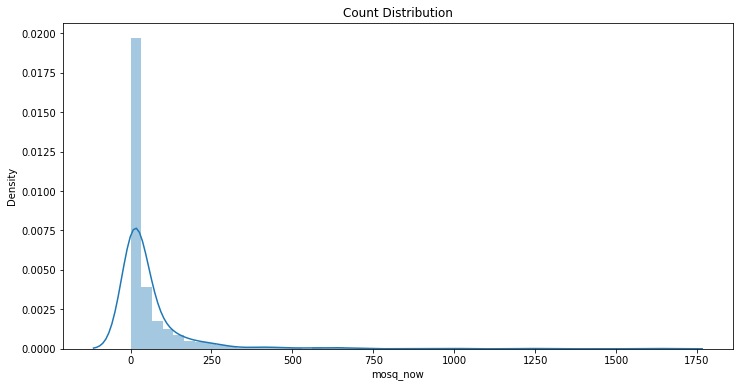

In [19]:
plt.figure(figsize=(12,6))
sns.distplot(mosquito_data_nuts2['mosq_now'])
plt.title('Count Distribution')
plt.show()

In [20]:
#quantile might change based on sns plots
mosq_quantilie = mosquito_data_nuts2['mosq_now'].quantile(0.90)

mosquito_data_nuts2['mosq_now'][mosquito_data_nuts2['mosq_now'] > mosq_quantilie] = mosq_quantilie+1

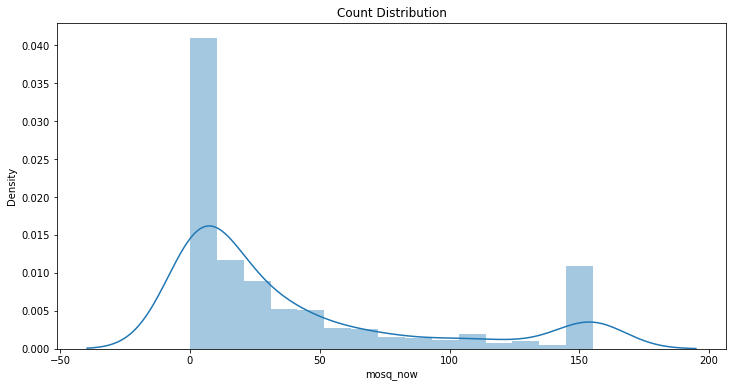

In [21]:
plt.figure(figsize=(12,6))
sns.distplot(mosquito_data_nuts2['mosq_now'])
plt.title('Count Distribution')
plt.show()

<AxesSubplot:>

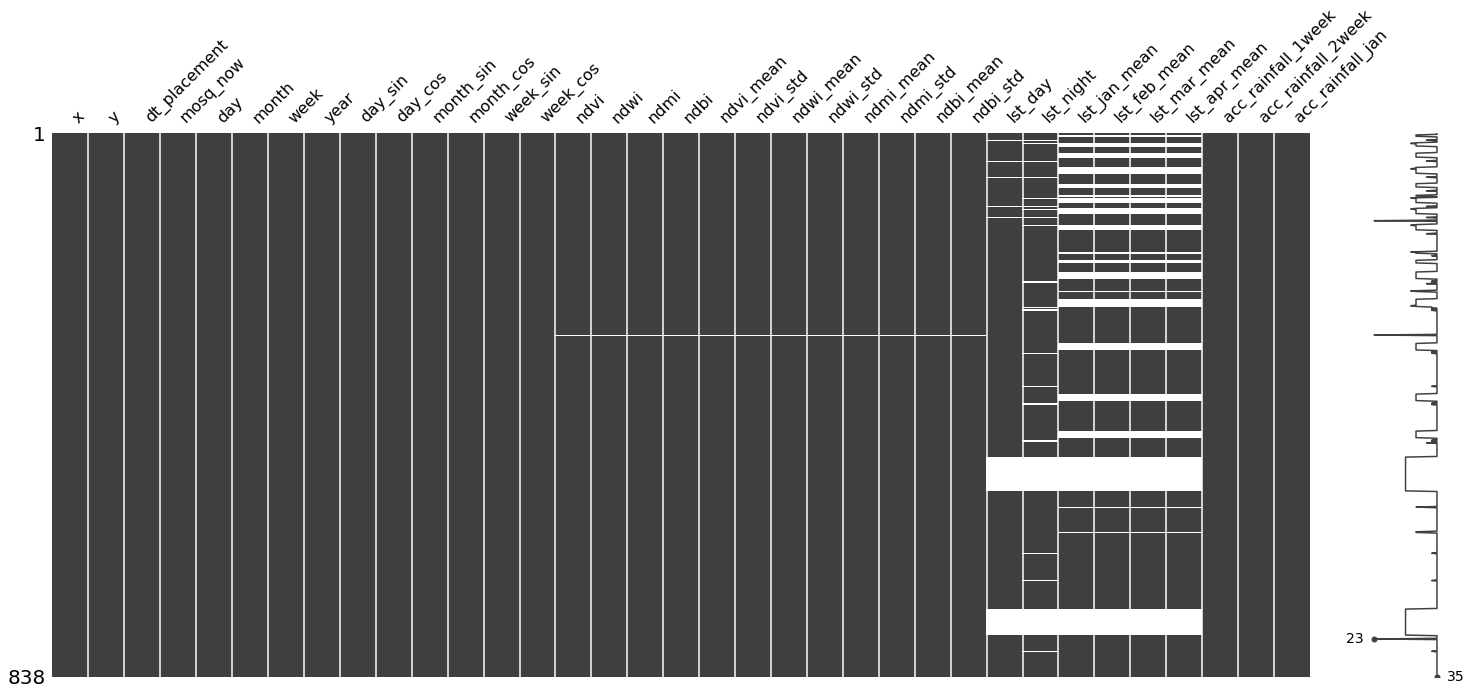

In [22]:
missingno.matrix(mosquito_data_nuts2)

In [23]:
imputer = KNNImputer()

features_for_impute = ['x', 'y', 'day', 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                        'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean', 'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 
                        'lst_day', 'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan']

mosquito_data_sub = mosquito_data_nuts2[features_for_impute]

imputed_data = pd.DataFrame(imputer.fit_transform(mosquito_data_sub), columns = mosquito_data_sub.columns)

In [24]:
imputed_columns = ['ndvi','ndmi', 'ndwi', 'ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std', 'ndmi_std','ndwi_std','ndbi_std',
                   'lst_day','lst_night','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean']

mosquito_data_nuts2[imputed_columns] = imputed_data[imputed_columns]

<AxesSubplot:>

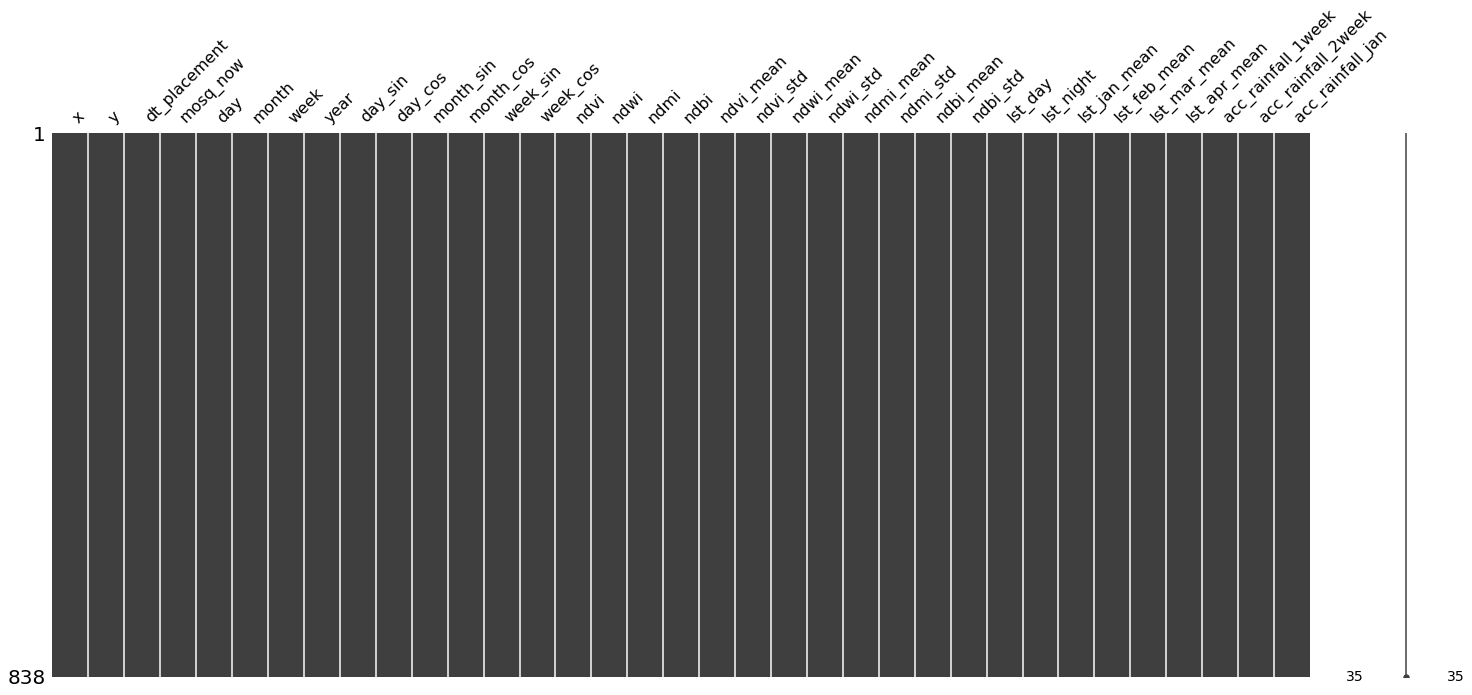

In [25]:
missingno.matrix(mosquito_data_nuts2)

In [26]:
step = 15
only_env = True
case_title = 'NN mosq regression'
exp = False
date_col = 'dt_placement'
model_type = 'mosquito_regression'
transform_target = True
augment = True

In [27]:
mosquito_data_nuts2 = initializer(mosquito_data_nuts2,2,10,25,step,[date_col], env=only_env, date_column = date_col, mosq_column='mosq_now')

Bounds: [  0.   16.5 155.3]


In [28]:
train_X, train_y, test_X, test_y, scaler = transformations(mosquito_data_nuts2, model_type = model_type, split = 0.25, augment=augment)

training_set = Dataset(train_X, train_y, model_type=model_type, transform = transform_target)
testing_set = Dataset(test_X, test_y, model_type=model_type, transform = transform_target)

model = FeedforwardNeuralNetModel(num_features=len(train_X[0]), num_class=1, hidden_layers = [264,128,128,64], dropout=0.2, model_type=model_type, transform = transform_target)

Epoch 001: | Train Loss: 42.09564 | Val Loss: 28.84749 | Train Acc: 4.505| Val Acc: 3.223
Epoch 002: | Train Loss: 38.89673 | Val Loss: 28.91017 | Train Acc: 3.884| Val Acc: 3.248
Epoch 003: | Train Loss: 36.65245 | Val Loss: 28.64563 | Train Acc: 3.441| Val Acc: 3.194
Epoch 004: | Train Loss: 35.14984 | Val Loss: 28.66726 | Train Acc: 3.157| Val Acc: 3.180
Epoch 005: | Train Loss: 34.43757 | Val Loss: 26.85067 | Train Acc: 2.950| Val Acc: 2.946
Epoch 006: | Train Loss: 33.98557 | Val Loss: 25.61625 | Train Acc: 2.853| Val Acc: 2.678
Epoch 007: | Train Loss: 33.49847 | Val Loss: 25.02733 | Train Acc: 2.791| Val Acc: 2.424
Epoch 008: | Train Loss: 33.31668 | Val Loss: 24.53092 | Train Acc: 2.743| Val Acc: 2.355
Epoch 009: | Train Loss: 32.97725 | Val Loss: 24.59349 | Train Acc: 2.685| Val Acc: 2.341
Epoch 010: | Train Loss: 32.95045 | Val Loss: 24.64043 | Train Acc: 2.685| Val Acc: 2.174
Epoch 011: | Train Loss: 32.79909 | Val Loss: 23.75339 | Train Acc: 2.692| Val Acc: 1.975
Epoch 012:

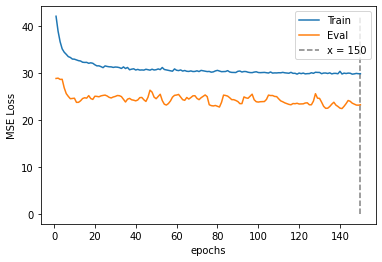

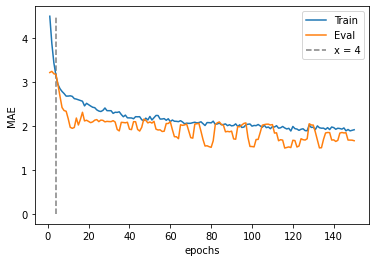

In [29]:
train, test, model = train_nn(model = model, learning_rate = 0.005, epochs = 150, batch_size = 128, train_set = training_set, test_set = testing_set, early_stop = False)

In [30]:
metrics(train, test, threshold=30)

MAE on train set:  21.692137478646206
min prediction: 1
max prediction: 207

MAE on test set:  23.56870266328827
Error ⩽ 30: 75.57 %
min prediction: 1
max prediction: 212


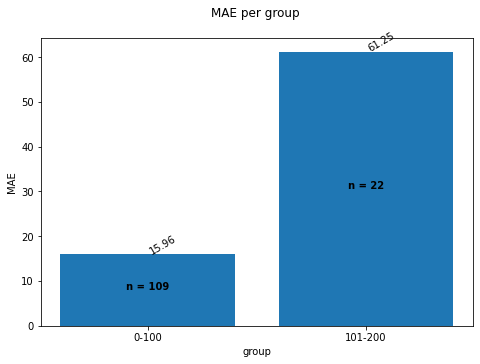

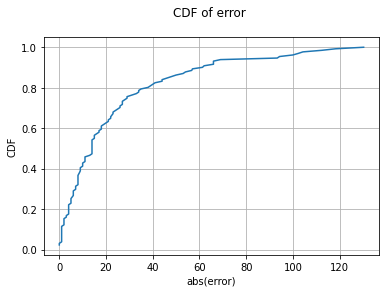

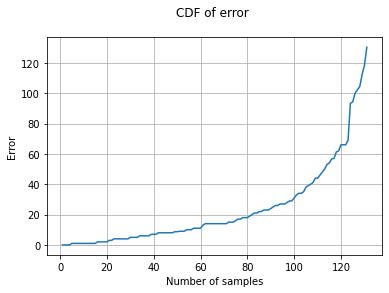

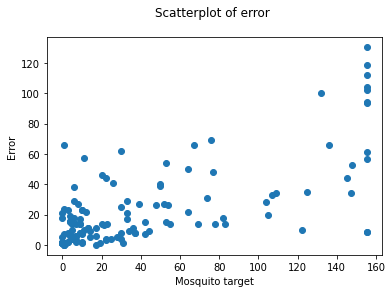

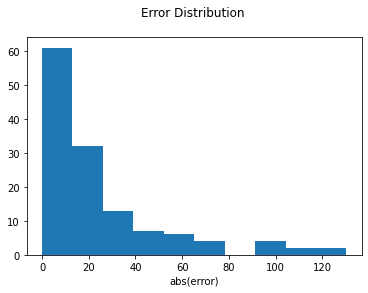

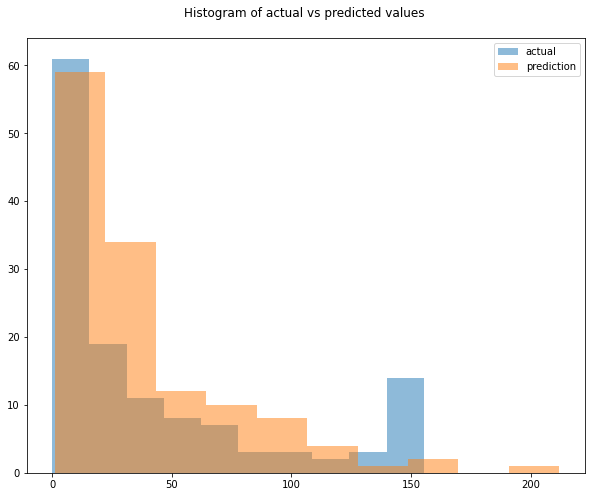

In [31]:
validation_plots(test,model_type)

Epoch 001: | Train Loss: 33.86206 | Val Loss: 0.18829 | Train Acc: 2.389| Val Acc: 0.045
Epoch 002: | Train Loss: 33.05566 | Val Loss: 0.10209 | Train Acc: 2.279| Val Acc: 0.045
Epoch 003: | Train Loss: 32.73901 | Val Loss: 0.02119 | Train Acc: 2.181| Val Acc: 0.045
Epoch 004: | Train Loss: 33.06049 | Val Loss: 0.03832 | Train Acc: 2.233| Val Acc: 0.045
Epoch 005: | Train Loss: 33.14389 | Val Loss: 0.18909 | Train Acc: 2.182| Val Acc: 0.045
Epoch 006: | Train Loss: 32.69676 | Val Loss: 0.02989 | Train Acc: 2.201| Val Acc: 0.045
Epoch 007: | Train Loss: 32.36213 | Val Loss: 0.07512 | Train Acc: 2.155| Val Acc: 0.045
Epoch 008: | Train Loss: 32.38652 | Val Loss: 0.25139 | Train Acc: 2.155| Val Acc: 0.045
Epoch 009: | Train Loss: 32.33726 | Val Loss: 0.15366 | Train Acc: 2.097| Val Acc: 0.045
Epoch 010: | Train Loss: 32.54443 | Val Loss: 0.00055 | Train Acc: 2.158| Val Acc: 0.045
Epoch 011: | Train Loss: 32.38219 | Val Loss: 0.04934 | Train Acc: 2.149| Val Acc: 0.045
Epoch 012: | Train Lo

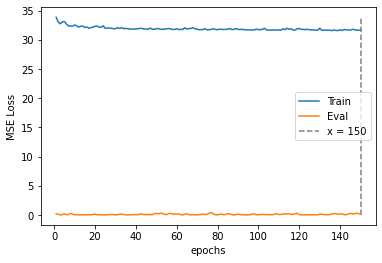

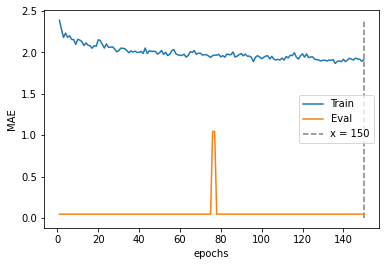

In [32]:
train_X, train_y, test_X, test_y, scaler = transformations(mosquito_data_nuts2, model_type = model_type, split = 0.000001, augment=augment)

training_set = Dataset(train_X, train_y, model_type=model_type, transform = transform_target)
testing_set = Dataset(test_X, test_y, model_type=model_type, transform = transform_target)

train, test, model = train_nn(model = model, learning_rate = 0.005, epochs = 150, batch_size = 128, train_set = training_set, test_set = testing_set, early_stop = False)

In [33]:
dataset_mamoth = dataset_mamoth_preparation(dataset, columns_to_keep)

In [34]:
mosqutio_predictions = dataset_mamoth[['x', 'y', 'dt_placement']].copy()

In [35]:
dataset_mamoth.drop(columns=['dt_placement'], inplace=True)

In [36]:
dataset_mamoth_sub = dataset_mamoth[features_for_impute]

In [37]:
mamoth_imputed = pd.DataFrame(imputer.transform(dataset_mamoth_sub), columns = dataset_mamoth_sub.columns)

In [38]:
dataset_mamoth[features_for_impute] = mamoth_imputed[features_for_impute]

<AxesSubplot:>

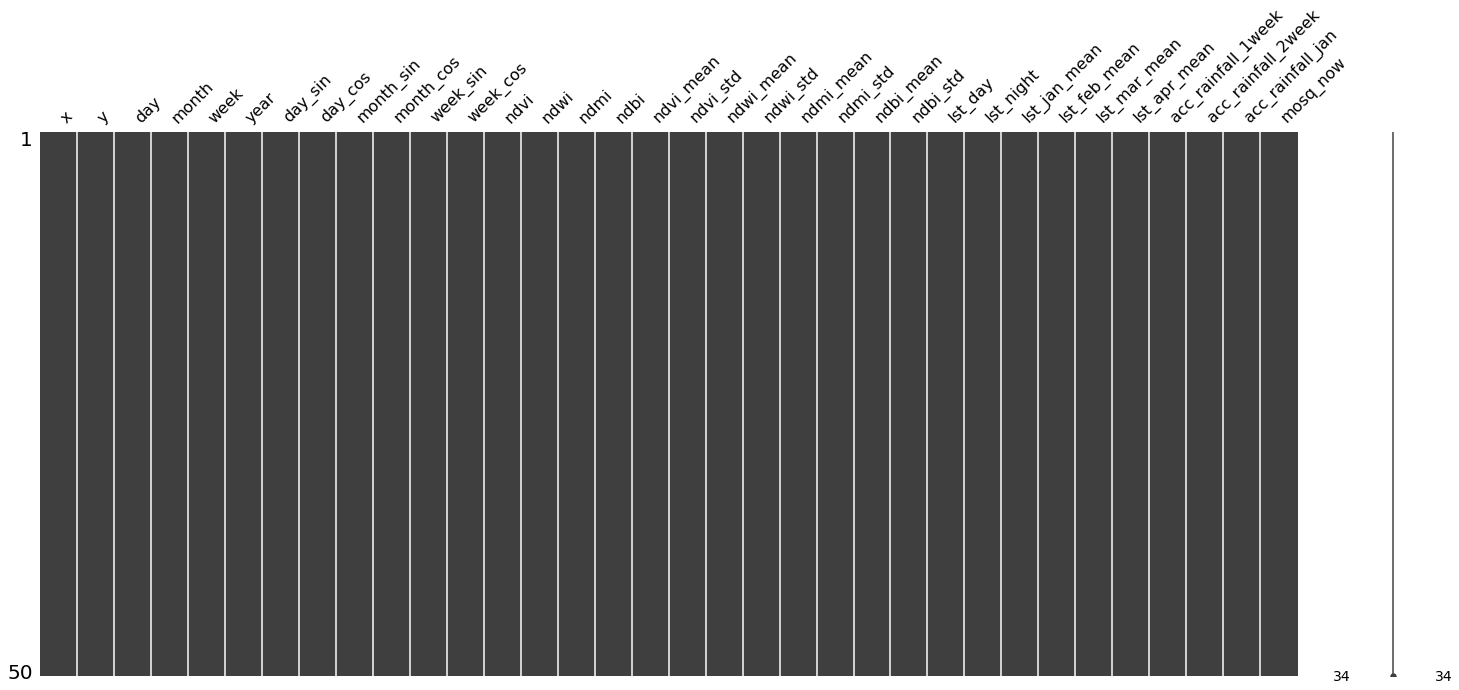

In [39]:
missingno.matrix(dataset_mamoth)

In [40]:
dataset_mamoth_X, dataset_mamoth_y = dataset_mamoth.iloc[:,:-1], dataset_mamoth.iloc[:,-1]

dataset_mamoth_X = scaler.transform(dataset_mamoth_X)

In [41]:
dataset_mamoth = Dataset(dataset_mamoth_X, dataset_mamoth_y, model_type=model_type, transform = transform_target)

In [42]:
predictions = give_predictions(model, dataset_mamoth)

In [43]:
mosqutio_predictions['mosq_pred'] = predictions

In [44]:
mosqutio_predictions

,x,y,dt_placement,mosq_pred
0,22.750267,39.710970,2023-05-01,35
1,22.692366,39.136391,2023-05-01,6
2,24.073790,39.328960,2023-05-01,1
3,21.430513,39.221380,2023-05-01,105
4,22.883800,39.351977,2023-05-01,30
...,...,...,...,...
45,22.553160,39.852112,2023-05-16,139
46,21.797560,39.635058,2023-05-16,77
47,22.343000,39.828472,2023-05-16,98
48,22.020557,39.603750,2023-05-16,110


In [45]:
mosqutio_predictions.to_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Predictions_2023-May.csv', index = False)